<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/airbnb_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Airbnb_Open_Data.csv',low_memory=False)

In [12]:
# pd.set_option('display.max_rows', None)

In [17]:
pd.reset_option('display.max_rows')

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.shape

(102599, 26)

In [7]:
df.select_dtypes(include=['object']).nunique()

,0
NAME,61281
host_identity_verified,2
host name,13190
neighbourhood group,7
neighbourhood,224
country,1
country code,1
instant_bookable,2
cancellation_policy,3
room type,4


In [22]:
df.drop(['id','host id','license','NAME','host name','country code','country','house_rules','license','last review'],axis=1,inplace=True)

In [23]:
df.shape

(102599, 17)

In [24]:
df.duplicated().sum()

np.int64(3636)

In [25]:
df.drop_duplicates(inplace=True)

In [27]:
df.shape

(98963, 17)

In [15]:
df['cancellation_policy'].value_counts()

,count
cancellation_policy,
moderate,34343
strict,34106
flexible,34074


In [20]:
print(df['neighbourhood'].value_counts().to_string())

neighbourhood
Bedford-Stuyvesant            7937
Williamsburg                  7775
Harlem                        5466
Bushwick                      4982
Hell's Kitchen                3965
Upper West Side               3860
Upper East Side               3680
East Village                  3492
Midtown                       3390
Crown Heights                 3262
East Harlem                   2341
Chelsea                       2285
Greenpoint                    2143
Lower East Side               1948
Astoria                       1876
Washington Heights            1779
Financial District            1490
West Village                  1484
Flatbush                      1295
East Flatbush                 1211
Prospect-Lefferts Gardens     1165
Long Island City              1150
Clinton Hill                  1140
Park Slope                    1007
Flushing                       985
Murray Hill                    960
Fort Greene                    949
Kips Bay                       920
Ridgew

In [28]:
df.select_dtypes(include=['object']).nunique()

,0
host_identity_verified,2
neighbourhood group,7
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4
price,1151
service fee,231


In [31]:
df['price']=df['price'].str.replace('$','')
df['price']=df['price'].str.replace(',','').astype('float64')
df['service fee']=df['service fee'].str.replace('$','')
df['service fee']=df['service fee'].str.replace(',','').astype('float64')

In [32]:
df.select_dtypes(include=['object']).nunique()

,0
host_identity_verified,2
neighbourhood group,7
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4


In [33]:
df.select_dtypes(include=['object']).columns

Index(['host_identity_verified', 'neighbourhood group', 'neighbourhood',
       'instant_bookable', 'cancellation_policy', 'room type'],
      dtype='object')

In [34]:
r=['host_identity_verified', 'neighbourhood group',
       'instant_bookable', 'cancellation_policy', 'room type']
for i in r:
  print(df[i].value_counts(),'\n')

host_identity_verified
unconfirmed    49400
verified       49274
Name: count, dtype: int64 

neighbourhood group
Manhattan        42292
Brooklyn         40317
Queens           12800
Bronx             2608
Staten Island      915
brookln              1
manhatan             1
Name: count, dtype: int64 

instant_bookable
False    49634
True     49224
Name: count, dtype: int64 

cancellation_policy
moderate    33133
flexible    32895
strict      32859
Name: count, dtype: int64 

room type
Entire home/apt    51908
Private room       44796
Shared room         2144
Hotel room           115
Name: count, dtype: int64 



In [35]:
df['neighbourhood group']=df['neighbourhood group'].replace('manhatan','Manhattan')
df['neighbourhood group']=df['neighbourhood group'].replace('brookln','Brooklyn')

In [36]:
df['neighbourhood group'].value_counts()

,count
neighbourhood group,
Manhattan,42293
Brooklyn,40318
Queens,12800
Bronx,2608
Staten Island,915


In [40]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
service fee,0.999991
number of reviews,0.004896
reviews per month,0.004164
long,0.002835
calculated host listings count,0.000621
availability 365,-0.001918
minimum nights,-0.003093
Construction year,-0.003807
review rate number,-0.004288


In [43]:
(df['service fee']/df['price']).describe()

,0
count,98477.000000
mean,0.199993
std,0.001151
min,0.192308
25%,0.199609
50%,0.200000
75%,0.200389
max,0.207547


In [44]:
df.drop(['service fee'],axis=1,inplace=True)

In [45]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
number of reviews,0.004896
reviews per month,0.004164
long,0.002835
calculated host listings count,0.000621
availability 365,-0.001918
minimum nights,-0.003093
Construction year,-0.003807
review rate number,-0.004288
lat,-0.005648


<Axes: >

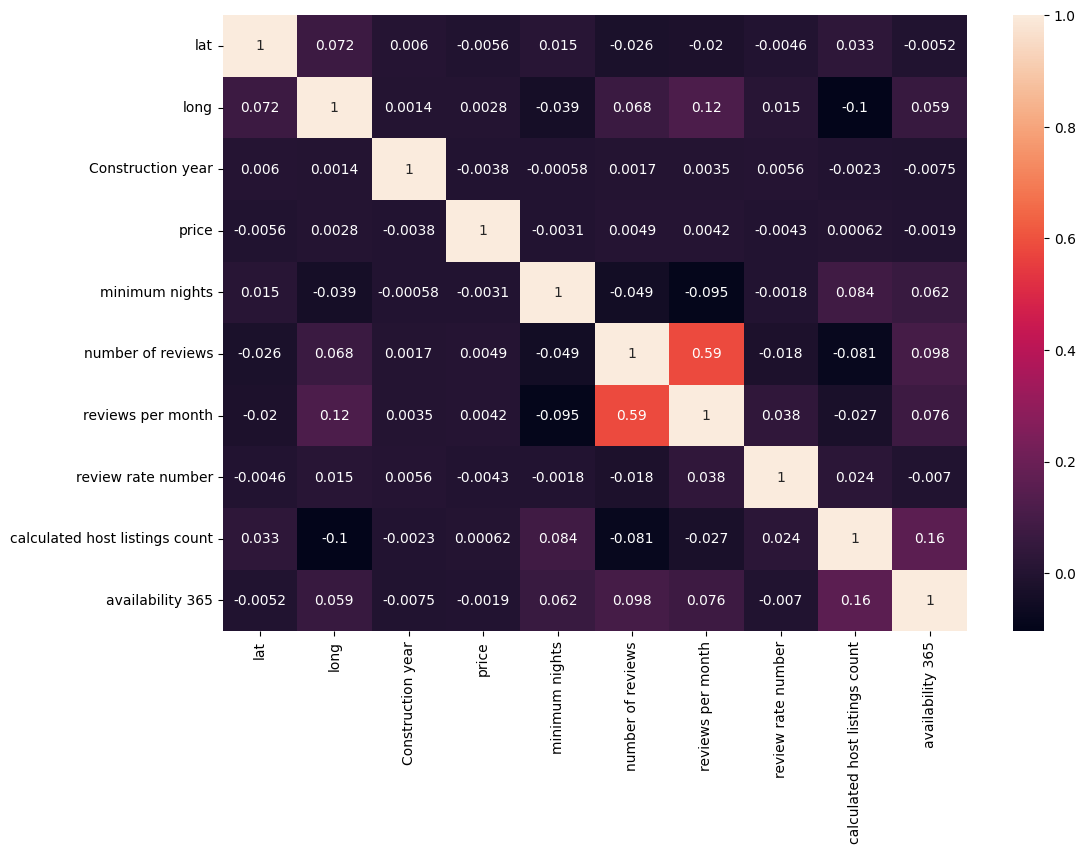

In [48]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [49]:
df.isna().sum()

,0
host_identity_verified,289
neighbourhood group,29
neighbourhood,16
lat,8
long,8
instant_bookable,105
cancellation_policy,76
room type,0
Construction year,214
price,247
